# 手写数字识别

## 导包

In [1]:
from keras.utils import to_categorical
import numpy as np
import os

In [2]:
from keras.datasets import mnist
(x_train_image, y_train_label), (x_test_image, y_test_label) = mnist.load_data()


## image预处理

In [3]:
print('x_train_image:', x_train_image.shape)
print('y_train_label:', y_train_label.shape)

x_train_image: (60000, 28, 28)
y_train_label: (60000,)


In [4]:
x_Train = x_train_image.reshape(60000, 784).astype('float32')
x_Test = x_test_image.reshape(10000, 784).astype('float32')

In [5]:
print('x_train:', x_Train.shape)
print('x_test:', x_Test.shape)

x_train: (60000, 784)
x_test: (10000, 784)


In [6]:
x_train_image[0]

array([[  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   3,
         18,  18,  18, 126, 136, 175,  26, 166, 255, 247, 127,   0,   0,
          0,   0],
       [  

In [7]:
x_Train_normalize = x_Train / 255
x_Test_normalize = x_Test / 255

In [8]:
y_train_label[:5]

array([5, 0, 4, 1, 9], dtype=uint8)

In [9]:
y_Train_OneHot = to_categorical(y_train_label)
y_Test_OneHot = to_categorical(y_test_label)

In [10]:
y_Train_OneHot[:5]

array([[0., 0., 0., 0., 0., 1., 0., 0., 0., 0.],
       [1., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 1., 0., 0., 0., 0., 0.],
       [0., 1., 0., 0., 0., 0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0., 0., 0., 0., 0., 1.]], dtype=float32)

## 建立模型

In [11]:
from keras.models import Sequential
from keras.layers import Dense

In [12]:
model = Sequential()

In [13]:
model.add(Dense(units=256, input_dim=784, kernel_initializer='normal', activation='relu'))

In [14]:
model.add(Dense(units=10, kernel_initializer='normal', activation='softmax'))

In [15]:
model.summary()

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 dense (Dense)               (None, 256)               200960    
                                                                 
 dense_1 (Dense)             (None, 10)                2570      
                                                                 
Total params: 203,530
Trainable params: 203,530
Non-trainable params: 0
_________________________________________________________________


In [16]:
model.compile(loss='categorical_crossentropy', optimizer='adam', metrics=['accuracy'])

## 训练模型

In [17]:
from keras.optimizers import SGD
opt = SGD(lr=0.03, momentum=0.9)
model.compile(optimizer=opt, loss='categorical_crossentropy', metrics=['accuracy'])
train_history = model.fit(x=x_Train_normalize, y = y_Train_OneHot, validation_split=0.2, epochs=30, batch_size=200, verbose=2)

Epoch 1/30


d:\Anaconda\envs\tensorflow210\lib\site-packages\keras\optimizers\optimizer_v2\gradient_descent.py:111: UserWarning: The `lr` argument is deprecated, use `learning_rate` instead.
  super().__init__(name, **kwargs)


240/240 - 2s - loss: 0.4962 - accuracy: 0.8621 - val_loss: 0.2684 - val_accuracy: 0.9241 - 2s/epoch - 10ms/step
Epoch 2/30
240/240 - 0s - loss: 0.2418 - accuracy: 0.9305 - val_loss: 0.2005 - val_accuracy: 0.9449 - 447ms/epoch - 2ms/step
Epoch 3/30
240/240 - 0s - loss: 0.1844 - accuracy: 0.9468 - val_loss: 0.1651 - val_accuracy: 0.9543 - 441ms/epoch - 2ms/step
Epoch 4/30
240/240 - 0s - loss: 0.1489 - accuracy: 0.9578 - val_loss: 0.1403 - val_accuracy: 0.9603 - 422ms/epoch - 2ms/step
Epoch 5/30
240/240 - 0s - loss: 0.1244 - accuracy: 0.9648 - val_loss: 0.1266 - val_accuracy: 0.9651 - 410ms/epoch - 2ms/step
Epoch 6/30
240/240 - 0s - loss: 0.1053 - accuracy: 0.9707 - val_loss: 0.1146 - val_accuracy: 0.9675 - 408ms/epoch - 2ms/step
Epoch 7/30
240/240 - 0s - loss: 0.0908 - accuracy: 0.9749 - val_loss: 0.1101 - val_accuracy: 0.9688 - 412ms/epoch - 2ms/step
Epoch 8/30
240/240 - 0s - loss: 0.0811 - accuracy: 0.9768 - val_loss: 0.0987 - val_accuracy: 0.9707 - 417ms/epoch - 2ms/step
Epoch 9/30
24

In [18]:
import matplotlib.pyplot as plt
def show_train_history(train_history, train, validation):
    plt.plot(train_history.history[train])
    plt.plot(train_history.history[validation])
    plt.title('Train History')
    plt.ylabel(train)
    plt.xlabel('Epoch')
    plt.legend(['train', 'validation'], loc='upper left')
    plt.show()

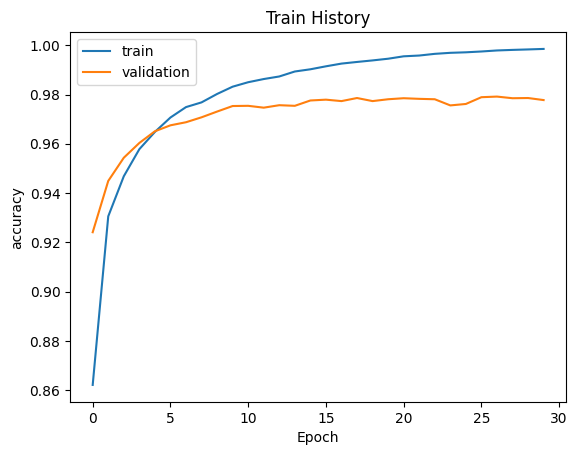

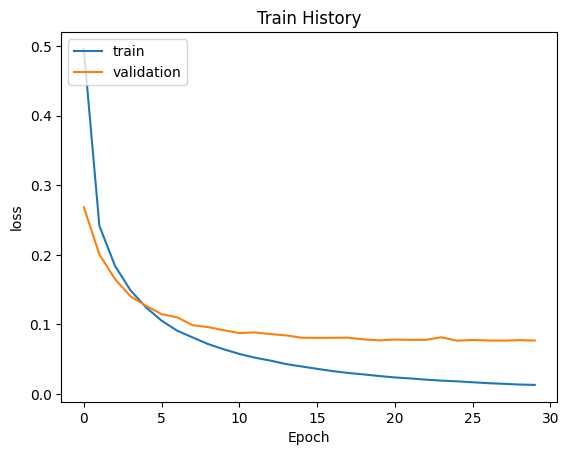

In [19]:
show_train_history(train_history, 'accuracy', 'val_accuracy')
show_train_history(train_history, 'loss', 'val_loss')

## 评估模型的准确率

In [ ]:
scores = model.evaluate(x_Test_normalize, y_Test_OneHot)
print()
print('accuracy=', scores[1])
print(scores)

313/313 [==============================] - 1s 2ms/step - loss: 0.0650 - accuracy: 0.9806

accuracy= 0.9805999994277954
[0.06503652781248093, 0.9805999994277954]


## 进行预测

In [21]:
prediction = model.predict(x_Test_normalize)
prediction_classes = prediction.argmax(axis=1)

313/313 [==============================] - 0s 837us/step


In [22]:
prediction_classes

array([7, 2, 1, ..., 4, 5, 6], dtype=int64)

In [23]:
import matplotlib.pyplot as plt
def plot_images_labels_prediction(images, label, prediction, index, num=10):
    fig = plt.gcf()
    fig.set_size_inches(12, 14)
    if num > 25: num = 25
    for i in range(0, num):
        ax = plt.subplot(5, 5, i+1)
        ax.imshow(images[index], cmap='binary')
        title = 'label=' + str(label[index])
        if len(prediction) > 0:
            title += ',predict=' + str(prediction[index])
        ax.set_title(title, fontsize=10)
        ax.set_xticks([]); ax.set_yticks([])
        index += 1
    plt.show()  

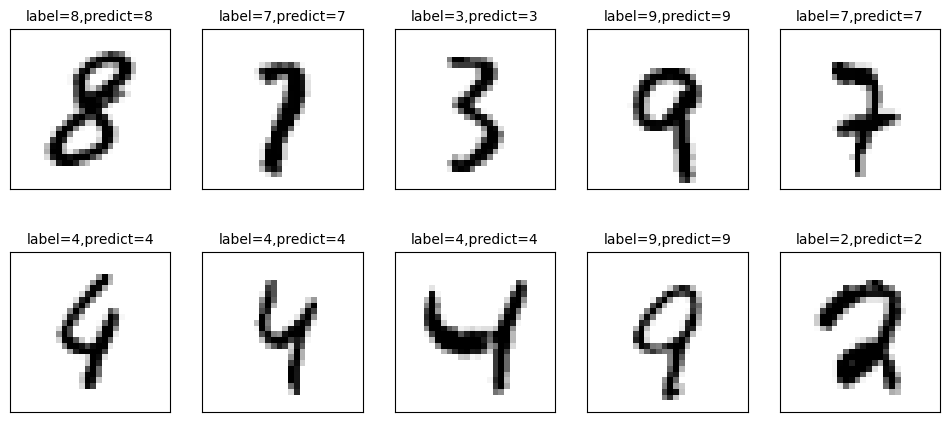

In [24]:
plot_images_labels_prediction(x_test_image, y_test_label, prediction_classes, index=110)

In [25]:
import pandas as pd
pd.crosstab(y_test_label, prediction_classes, rownames=['label'], colnames=['predict'])

predict,0,1,2,3,4,5,6,7,8,9
label,,,,,,,,,,
0,972,0,1,1,1,1,1,1,1,1
1,0,1127,2,1,0,1,2,1,1,0
2,5,1,1007,1,3,0,1,9,5,0
3,0,0,2,999,0,4,0,2,3,0
4,1,0,1,1,961,0,4,2,2,10
5,4,0,0,9,2,863,7,1,4,2
6,5,3,0,1,2,3,942,0,2,0
7,0,4,5,2,0,0,0,1011,3,3
8,4,0,1,7,4,3,3,4,945,3
